<a href="https://colab.research.google.com/github/ParasRajputt/Deep_Learning_Pytorch/blob/main/Pytorch_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
X, y = make_circles(
    n_samples=10000,
    random_state=42,
    noise = 0.05
)

In [ ]:
df = pd.DataFrame({"X1" : X[:,0],
                   "X2":X[:,1],
                  "label": y})

In [ ]:
print(df['label'].value_counts())

label
1    5000
0    5000
Name: count, dtype: int64


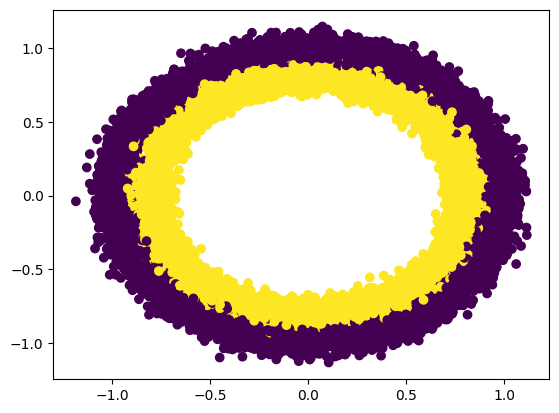

In [ ]:
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y)

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2 , random_state = 42)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
import torch
from torch import nn

class Circles_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=50)
        self.layer3 = nn.Linear(in_features=50, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model = Circles_Model()
print(model)



Circles_Model(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
optimizer = torch.optim.SGD(params = model.parameters(),
                            lr = 0.1)

In [ ]:

torch.manual_seed(42)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

epochs = 1000
for epoch in range(epochs):
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss & training accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    # 3. Optimizer zero grad, backprop, & step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 4. Evaluation
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    # 5. Print results
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:3d} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch:   0 | Loss: 0.65027, Acc: 64.62% | Test Loss: 0.65039, Test Acc: 64.90%
Epoch: 100 | Loss: 0.63366, Acc: 68.14% | Test Loss: 0.63336, Test Acc: 67.50%
Epoch: 200 | Loss: 0.61038, Acc: 72.67% | Test Loss: 0.60962, Test Acc: 71.85%
Epoch: 300 | Loss: 0.57235, Acc: 76.40% | Test Loss: 0.57137, Test Acc: 76.75%
Epoch: 400 | Loss: 0.51766, Acc: 81.15% | Test Loss: 0.51748, Test Acc: 81.35%
Epoch: 500 | Loss: 0.44125, Acc: 87.33% | Test Loss: 0.44336, Test Acc: 87.30%
Epoch: 600 | Loss: 0.34734, Acc: 92.42% | Test Loss: 0.35072, Test Acc: 92.35%
Epoch: 700 | Loss: 0.25543, Acc: 96.47% | Test Loss: 0.26161, Test Acc: 96.00%
Epoch: 800 | Loss: 0.19187, Acc: 97.19% | Test Loss: 0.19871, Test Acc: 96.60%
Epoch: 900 | Loss: 0.15425, Acc: 97.41% | Test Loss: 0.16106, Test Acc: 96.75%


In [ ]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries for 2D datasets using Matplotlib."""
    # Ensure model and data are on CPU
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # 1. Define grid bounds around the feature space
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 101),
        np.linspace(y_min, y_max, 101)
    )

    # 2. Convert mesh grid coordinates into a PyTorch tensor
    X_to_pred = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

    # 3. Make predictions on every point on the grid
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred)

    # Convert logits to class labels (handles binary vs multi-class)
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))

    # 4. Reshape predictions to match grid dimensions
    Z = y_pred.reshape(xx.shape).numpy()

    # 5. Plot decision regions and overlay scatter plot data
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors="k")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

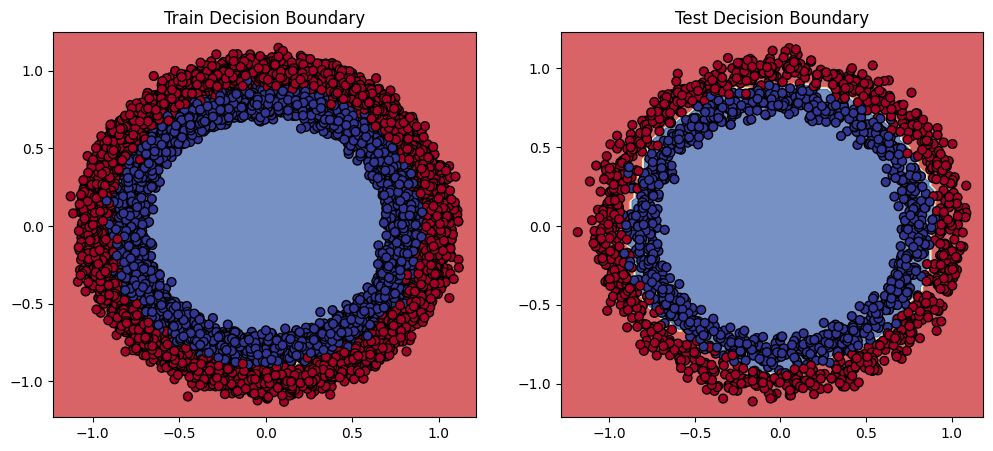

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Train Decision Boundary")
plot_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test Decision Boundary")
plot_decision_boundary(model, X_test, y_test)

plt.show()

In [ ]:
from pathlib import Path
import torch

# 1. Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "circles_model.pth"

# 2. Save state dictionary
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/circles_model.pth


1. Binary Classification with Neural Networks
   - make_circles — non-linearly separable data
   - Logistic Regression would fail here — needs neural network

2. Model Architecture
   - Input layer → hidden layers with ReLU → output layer (no activation)
   - ReLU in hidden layers = non-linearity
   - No ReLU at output = let loss function handle it

3. Loss Function
   - BCEWithLogitsLoss = sigmoid + binary cross entropy combined
   - More numerically stable than BCELoss + manual sigmoid

4. Key Concept
   - Without ReLU: stacked linear layers = one linear layer (useless)
   - With ReLU: network can learn curved/complex decision boundaries

5. Training Loop — same pattern as Chapter 1
   - Only difference: squeeze() needed for binary classification output